In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_hub as hub
from tensorflow.keras import layers

In [ ]:
from google.colab import drive

# Mount to /content/drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Access your data through the mounted drive
data_path = '/content/drive/MyDrive/DDA sem3/acne_data' # Path to your data within the drive

In [ ]:
!pip install split-folders
import splitfolders
splitfolders.ratio('/content/drive/MyDrive/DDA sem3/acne_data', output="output", seed=1337, ratio=(0.8, 0.2))

Copying files: 999 files [00:07, 130.41 files/s]


In [ ]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "/content/output/train/"
test_dir = "/content/output/val/"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=16,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)
valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=16,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

Found 798 images belonging to 3 classes.
Found 201 images belonging to 3 classes.


In [ ]:
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url(str): A TensorFlow Hub feature extraction URL.
    num_classes(int): Number of output neurons in the output layer,
      should be equal to number of target classes, default = 10

  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor
    layer and Dense output layer with num_classes output neurons.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="feature_extraction_layer",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
     feature_extractor_layer,    # use the feature extraction layer as the base
     layers.Dense(num_classes, activation="softmax", name="output_layer")   # create our own output layer
  ])
  return model

In [ ]:
#!pip install tensorflow==2.15.0 tensorflow-hub keras==2.15.0

import tensorflow_hub as hub
import tensorflow as tf
from tensorflow.keras import layers

# ... (rest of your code)

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.
  """
  # Download the pretrained model and save it as a Keras layer
  # Moved feature_extractor_layer definition inside create_model function
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="feature_extraction_layer",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
     tf.keras.layers.InputLayer(input_shape=IMAGE_SHAPE + (3,)), # Add an InputLayer
     feature_extractor_layer,
     layers.Dense(num_classes, activation="softmax", name="output_layer")
  ])
  return model

In [ ]:
#!ls /content/output/train/
#!ls /content/output/val/

In [ ]:
# Create EfficientNet model
efficientnet_model = create_model(efficientnet_url,
                            num_classes=3)
# Compile
efficientnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])
# Fit the model
efficientnet_history = efficientnet_model.fit(train_data,
                                  epochs=5,
                                  validation_data=valid_data)   # name of log files

Epoch 1/5
50/50 [==============================] - 80s 1s/step - loss: 0.9978 - accuracy: 0.4624 - val_loss: 0.9082 - val_accuracy: 0.5025
Epoch 2/5
50/50 [==============================] - 79s 2s/step - loss: 0.8878 - accuracy: 0.5301 - val_loss: 0.8285 - val_accuracy: 0.6020
Epoch 3/5
50/50 [==============================] - 70s 1s/step - loss: 0.8079 - accuracy: 0.6128 - val_loss: 0.7888 - val_accuracy: 0.6617
Epoch 4/5
50/50 [==============================] - 70s 1s/step - loss: 0.7702 - accuracy: 0.6554 - val_loss: 0.7701 - val_accuracy: 0.6567
Epoch 5/5
50/50 [==============================] - 69s 1s/step - loss: 0.7343 - accuracy: 0.6792 - val_loss: 0.7435 - val_accuracy: 0.6965


In [ ]:
efficientnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feature_extraction_layer (  (None, 1280)              4049564   
 KerasLayer)                                                     
                                                                 
 output_layer (Dense)        (None, 3)                 3843      
                                                                 
Total params: 4053407 (15.46 MB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 4049564 (15.45 MB)
_________________________________________________________________


In [ ]:
efficientnet_model.save('/contents/saved_model/my_model')

TypeError: in user code:

    File "/usr/local/lib/python3.10/dist-packages/keras/src/saving/legacy/saving_utils.py", line 147, in _wrapped_model  *
        outputs = model(*args, **kwargs)
    File "/usr/local/lib/python3.10/dist-packages/keras/src/utils/traceback_utils.py", line 70, in error_handler  **
        raise e.with_traceback(filtered_tb) from None

    TypeError: Exception encountered when calling layer 'sequential' (type Sequential).
    
    Binding inputs to tf.function failed due to `missing a required argument: 'inputs'`. Received args: (<tf.Tensor 'input_1:0' shape=(None, 224, 224, 3) dtype=float32>,) and kwargs: {'training': False} for signature: (self, inputs, training=<captured_default_value>).
    
    Call arguments received by layer 'sequential' (type Sequential):
      • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
      • training=False
      • mask=None


In [ ]:
acne_model = tf.keras.models.load_model('saved_model/my_model')

# Check its architecture
acne_model.summary()

OSError: No file or directory found at saved_model/my_model

In [ ]:
import pathlib
data_dir = pathlib.Path(train_dir)
acne_class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(acne_class_names)

['Level_0' 'Level_1' 'Level_2']


In [ ]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads in an image from filename, turns it into a tensor and reshapes into (224,224,3).
  """
  # Read in the image
  img = tf.io.read_file(filename)
  # Decode it into a tensor
  img = tf.image.decode_jpeg(img)
  # Resize the image
  img = tf.image.resize(img, [img_shape, img_shape])
  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [ ]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model, filename, class_names=acne_class_names):
  """
  Imports an image located at filename, makes a prediction with model
  and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Add in logic for multi-class & get pred_class name
  if len(pred[0]) > 1:
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred[0]))]

  print('Prediction Probabilities : ', pred[0])

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

In [ ]:
 pred_and_plot(model=acne_model,
              filename="/content/download.jpeg",
              class_names=acne_class_names)

NameError: name 'acne_model' is not defined

#skin type model

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install split-folders
import splitfolders
# Remove trailing space from the input path
input_folder = "/content/drive/MyDrive/DDA sem3/skin_type data"

# Split the data
splitfolders.ratio(input_folder, output="output2", seed=1337, ratio=(0.8, 0.2))

Copying files: 1275 files [00:26, 48.28 files/s] 


In [ ]:
# Setup data inputs
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Preprocess data (get all of the pixel values between 0 & 1, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup paths to our data directories
train_dir = "/content/output2/train"
# Changed test_dir to val_dir to match the output of splitfolders.ratio()
val_dir = "/content/output2/val"


# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)
# Use val_dir instead of test_dir for valid_data
valid_data = valid_datagen.flow_from_directory(directory=val_dir,
                                               target_size=(224, 224),
                                               class_mode="categorical",
                                               seed=42)

Found 1016 images belonging to 3 classes.
Found 257 images belonging to 3 classes.


In [ ]:
print(train_data.class_indices)
print(valid_data.class_indices)


{'dry': 0, 'normal': 1, 'oily': 2}
{'dry': 0, 'normal': 1, 'oily': 2}


In [ ]:
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

IMAGE_SHAPE = (224, 224)
BATCH_SIZE = 32

def create_model(model_url, num_classes=3):
  """
  Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url(str): A TensorFlow Hub feature extraction URL.
    num_classes(int): Number of output neurons in the output layer,
      should be equal to number of target classes, default = 10

  Returns:
    An uncompiled Keras Sequential model with model_url as feature extractor
    layer and Dense output layer with num_classes output neurons.
  """
  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                           trainable = False,   # freeze the already learned patterns
                                           name="EfficientnetB0_model",
                                           input_shape=IMAGE_SHAPE+(3,))  # define the input image shape
  # Create our image model
  model = tf.keras.Sequential([
    feature_extractor_layer,    # use the feature extraction layer as the base
    layers.Dense(num_classes, activation="softmax", name="output_layer")   # create our own output layer
  ])
  return model

In [ ]:
def create_model(model_url, num_classes=3):
    """
    Creates a Keras model using a TensorFlow Hub model as a feature extractor.
    Args:
      model_url (str): TensorFlow Hub URL for the model.
      num_classes (int): Number of output classes for classification.
    """
    # Input layer for 224x224 images with 3 channels (RGB)
    input_layer = tf.keras.layers.Input(shape=(224, 224, 3))
    print("Input layer defined")

    # Feature extractor from TensorFlow Hub (set trainable=False)
    feature_extractor_layer = hub.KerasLayer(model_url, trainable=False)
    print("Feature extractor layer created")

    # Wrap the feature extractor layer in a Lambda layer to handle the KerasTensor
    # This Lambda layer converts the KerasTensor to a regular TensorFlow tensor
    extracted_features = tf.keras.layers.Lambda(lambda x: feature_extractor_layer(x))(input_layer)
    print("Extracted features shape: ", extracted_features.shape)

    # Output layer with softmax activation for classification
    output_layer = tf.keras.layers.Dense(num_classes, activation="softmax")(extracted_features)
    print("Output layer created")

    # Create the model using Functional API
    model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
    print("Model created")

    return model

In [ ]:
# URL of EfficientNet B0 from TensorFlow Hub
efficientnet_url = "https://tfhub.dev/tensorflow/efficientnet/b0/feature-vector/1"

In [ ]:
# Create the model
efficientnet_model = create_model(efficientnet_url, num_classes=3)

Input layer defined
Feature extractor layer created


The following Variables were used a Lambda layer's call (lambda), but
are not present in its tracked objects:
  <tf.Variable 'top_bn/beta:0' shape=(1280,) dtype=float32>
  <tf.Variable 'top_bn/gamma:0' shape=(1280,) dtype=float32>
  <tf.Variable 'top_conv2d/kernel:0' shape=(1, 1, 320, 1280) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_bn/beta:0' shape=(320,) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_bn/gamma:0' shape=(320,) dtype=float32>
  <tf.Variable 'stack_6/block_0/project_conv2d/kernel:0' shape=(1, 1, 1152, 320) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_expand_conv2d/bias:0' shape=(1152,) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_expand_conv2d/kernel:0' shape=(1, 1, 48, 1152) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_reduce_conv2d/bias:0' shape=(48,) dtype=float32>
  <tf.Variable 'stack_6/block_0/se_reduce_conv2d/kernel:0' shape=(1, 1, 1152, 48) dtype=float32>
  <tf.Variable 'stack_6/block_0/depthwise_bn/beta:0' shape=(1152,) dtype=f

Extracted features shape:  (None, 1280)
Output layer created
Model created


In [ ]:
# Compile
efficientnet_model.compile(loss="categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [ ]:
efficientnet_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 lambda (Lambda)             (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 3)                 3843      
                                                                 
Total params: 3843 (15.01 KB)
Trainable params: 3843 (15.01 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Fit the model
efficientnet_history = efficientnet_model.fit(train_data,
                                  epochs=5,
                                  validation_data=valid_data)   # name of log files

Epoch 1/5
32/32 [==============================] - 164s 3s/step - loss: 0.9378 - accuracy: 0.5778 - val_loss: 0.8171 - val_accuracy: 0.6537
Epoch 2/5
32/32 [==============================] - 84s 3s/step - loss: 0.7061 - accuracy: 0.7205 - val_loss: 0.7158 - val_accuracy: 0.7237
Epoch 3/5
32/32 [==============================] - 91s 3s/step - loss: 0.6083 - accuracy: 0.7766 - val_loss: 0.6621 - val_accuracy: 0.7393
Epoch 4/5
32/32 [==============================] - 84s 3s/step - loss: 0.5509 - accuracy: 0.8041 - val_loss: 0.6284 - val_accuracy: 0.7393
Epoch 5/5
32/32 [==============================] - 85s 3s/step - loss: 0.5053 - accuracy: 0.8238 - val_loss: 0.6003 - val_accuracy: 0.7626


In [ ]:
import pathlib
data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))
print(class_names)

['dry' 'normal' 'oily']


In [ ]:
# Reconfig pred_and_plot function to work with multi-class images
def pred_and_plot(model, filename, class_names=class_names):
  """
  Imports an image located at filename, makes a prediction with model
  and plots the image with the predicted class as the title.
  """
  # Import the target image and preprocess it
  img = load_and_prep_image(filename)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))

  # Add in logic for multi-class & get pred_class name
  if len(pred[0]) > 1:
    pred_class = class_names[tf.argmax(pred[0])]
  else:
    pred_class = class_names[int(tf.round(pred[0]))]

  print('Prediction Probabilities : ', pred[0])

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False);

1/1 [==============================] - 4s 4s/step
Prediction Probabilities :  [0.35855743 0.15353246 0.48791003]


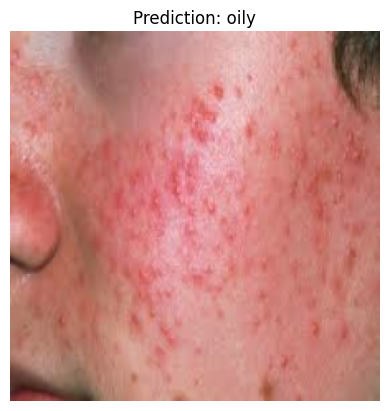

In [ ]:
# Make a prediction using model_1
pred_and_plot(model=efficientnet_model,
              filename="/content/download.jpeg",
              class_names=class_names)

In [ ]:
# Assuming `efficientnet_model` is your skin type model
# Assuming `acne_model` is your acne level model
# Assuming `class_names` is the list of class names for skin type model
# Assuming `class_names_acne` is the list of class names for acne model

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define a function that takes an image path and predicts skin type and acne level
def predict_skin_attributes(image_path, acne_model, efficientnet_model, class_names, class_names_acne):
    # Load and preprocess the image
    img = load_and_prep_image(image_path)

    # Make predictions with both models
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = efficientnet_model.predict(tf.expand_dims(img, axis=0))

    # Get predicted class names for both models
    acne_class = acne_class_names[tf.argmax(acne_pred[0])]
    skin_type_class = class_names[tf.argmax(skin_type_pred[0])]

    # Print predictions and their probabilities
    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    # Combine predictions into a single user vector
    user_vector = np.concatenate((acne_pred[0], skin_type_pred[0]))
    return user_vector

# Path to the input image
image_path = '/content/download.jpeg'  # Replace with the path to your test image

# Get the user vector for recommendation
user_vector = predict_skin_attributes(image_path, acne_model, efficientnet_model, class_names, acne_class_names)



1/1 [==============================] - 0s 72ms/step
Acne Level: Level_2, Prediction Probabilities: [0.366445   0.2593222  0.37423274]
Skin Type: oily, Prediction Probabilities: [0.35855743 0.15353246 0.48791003]


In [ ]:
user_vector

array([0.366445  , 0.2593222 , 0.37423274, 0.35855743, 0.15353246,
       0.48791003], dtype=float32)

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

def pred_and_plot_both_models(image_path, acne_model, efficientnet_model, class_names_acne, class_names_skin):
    """
    Loads an image, predicts acne level and skin type, and displays the image with predictions.
    Args:
        image_path (str): Path to the input image.
        acne_model: Trained model for acne level detection.
        efficientnet_model: Trained model for skin type detection.
        class_names_acne (list): Class names for acne model (e.g., ["level0", "level1", "level2"]).
        class_names_skin (list): Class names for skin type model (e.g., ["oily", "dry", "normal"]).
    """
    # Load and preprocess the image
    img = load_and_prep_image(image_path)

    # Make predictions using both models
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = efficientnet_model.predict(tf.expand_dims(img, axis=0))

    # Get predicted classes
    acne_class = acne_class_names[tf.argmax(acne_pred[0])]
    skin_type_class = class_names_skin[tf.argmax(skin_type_pred[0])]

    # Display the predictions
    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    # Plot the image with predictions as overlay text
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Skin Type: {skin_type_class} ({max(skin_type_pred[0]):.2f}) | Acne Level: {acne_class} ({max(acne_pred[0]):.2f})", fontsize=12)
    plt.show()




1/1 [==============================] - 0s 111ms/step
Acne Level: Level_2, Prediction Probabilities: [0.366445   0.2593222  0.37423274]
Skin Type: oily, Prediction Probabilities: [0.35855743 0.15353246 0.48791003]


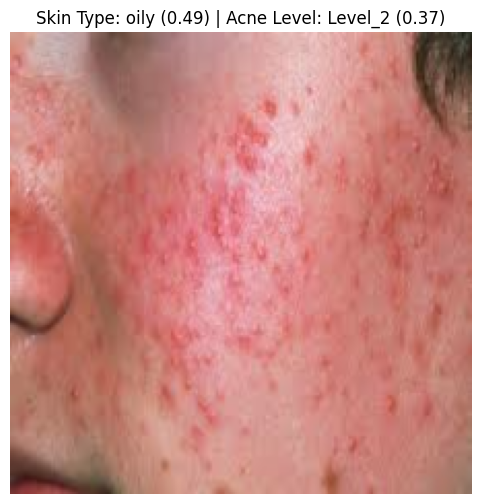

In [ ]:
image_path = "/content/download.jpeg"
pred_and_plot_both_models(image_path, acne_model, efficientnet_model, acne_class_names, class_names)

In [ ]:
acne_model.save('/content/drive/MyDrive/DDA sem3/saved_model/acne_model.keras')

NameError: name 'acne_model' is not defined

In [ ]:
# Save using the recommended Keras format
efficientnet_model.save('/content/drive/MyDrive/DDA sem3/saved_model/efficientnet_model.keras')


# run the below code to load and get the output

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths to models in Google Drive
acne_model_path = '/content/drive/MyDrive/DDA sem3/saved_model/acne_model'  # Saved as .keras
skin_type_model_path = '/content/drive/MyDrive/DDA sem3/saved_model/efficientnet_model.keras'  # Saved as .keras

# Load your models only if they are not already loaded
try:
    acne_model
    skin_type_model
except NameError:
    from tensorflow.keras.models import load_model
    acne_model = load_model(acne_model_path)
    skin_type_model = load_model(skin_type_model_path)
    print("Models loaded successfully.")

# Placeholder class names if not defined
class_names = ["oily", "dry", "normal"]  # Update with actual skin type classes
acne_class_names = ["level0", "level1", "level2"]  # Update with actual acne levels

# Function to preprocess the image
def load_and_prep_image(image_path, img_shape=224):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, [img_shape, img_shape])
    img = img / 255.0  # Scale to [0, 1] range
    return img

# Define the prediction function
def predict_skin_attributes(image_path, acne_model, skin_type_model, class_names, class_names_acne):
    img = load_and_prep_image(image_path)
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = skin_type_model.predict(tf.expand_dims(img, axis=0))

    acne_class = class_names_acne[tf.argmax(acne_pred[0])]
    skin_type_class = class_names[tf.argmax(skin_type_pred[0])]

    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    user_vector = np.concatenate((acne_pred[0], skin_type_pred[0]))
    return user_vector

# Define the function to display image with predictions
def pred_and_plot_both_models(image_path, acne_model, skin_type_model, class_names_acne, class_names_skin):
    img = load_and_prep_image(image_path)
    acne_pred = acne_model.predict(tf.expand_dims(img, axis=0))
    skin_type_pred = skin_type_model.predict(tf.expand_dims(img, axis=0))

    acne_class = class_names_acne[tf.argmax(acne_pred[0])]
    skin_type_class = class_names_skin[tf.argmax(skin_type_pred[0])]

    print(f"Acne Level: {acne_class}, Prediction Probabilities: {acne_pred[0]}")
    print(f"Skin Type: {skin_type_class}, Prediction Probabilities: {skin_type_pred[0]}")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Skin Type: {skin_type_class} ({max(skin_type_pred[0]):.2f}) | Acne Level: {acne_class} ({max(acne_pred[0]):.2f})", fontsize=12)
    plt.show()

# Main function to call predictions with a new image
def main(image_path):
    user_vector = predict_skin_attributes(image_path, acne_model, skin_type_model, class_names, acne_class_names)
    pred_and_plot_both_models(image_path, acne_model, skin_type_model, acne_class_names, class_names)
    return user_vector

# Example usage
image_path = "/content/download.jpeg"  # Replace this path with any new image path
user_vector = main(image_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ValueError: File format not supported: filepath=/content/drive/MyDrive/DDA sem3/saved_model/acne_model. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/content/drive/MyDrive/DDA sem3/saved_model/acne_model, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

1/1 [==============================] - 0s 72ms/step
Acne Level: Level_0, Prediction Probabilities: [0.51093686 0.42888772 0.06017543]
Skin Type: dry, Prediction Probabilities: [0.55364066 0.12041152 0.32594782]
1/1 [==============================] - 0s 74ms/step
Acne Level: Level_0, Prediction Probabilities: [0.51093686 0.42888772 0.06017543]
Skin Type: dry, Prediction Probabilities: [0.55364066 0.12041152 0.32594782]


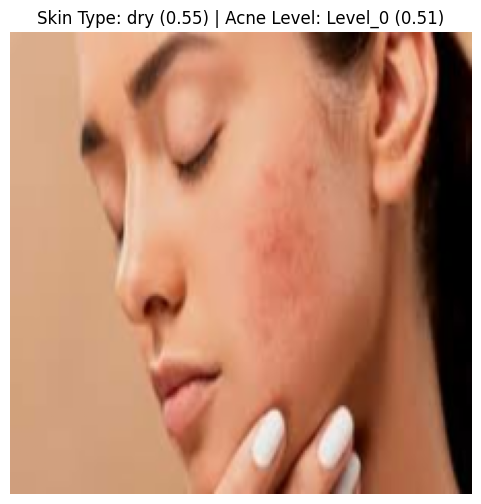

In [ ]:
# Example usage
image_path = "/download2.jpg"  # Replace this path with any new image path
user_vector = main(image_path)

# skin care recommendation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import heapq

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#importing data set
df = pd.read_csv("/content/drive/MyDrive/DDA sem3/result.csv")
df.head()

,label,url,brand,name,price,skin type,spf,concern,concern 2,concern 3,key ingredient,formulation
0,face-moisturisers,https://www.myntra.com/face-moisturisers/lakme...,Lakme,Absolute Perfect Radiance Skin Lightening Day ...,₹ 79,All,NaN,General Care,NaN,NaN,NaN,Cream
1,face-moisturisers,https://www.myntra.com/face-moisturisers/bioti...,Biotique,Bio Morning Nectar Flawless Sustainable Skin M...,₹ 165,All,NaN,Uneven Skin Tone,Hydration,Dark Spots,Honey,Lotion
2,face-moisturisers,https://www.myntra.com/face-moisturisers/nivea...,Nivea,Unisex Aloe Hydration Skin Cream 100 ml,₹ 92,All,NaN,Dull Skin,Dryness,General Care,Aloe Vera,Cream
3,face-moisturisers,https://www.myntra.com/face-moisturisers/vi-jo...,VI-JOHN,Women Set of 5 Saffron Fairness Cream Advanced,₹ 187,All,15 to 30,Softening and Smoothening,Softening and Smoothening,Sun Protection,Vitamin E,Cream
4,face-moisturisers,https://www.myntra.com/face-moisturisers/lakme...,Lakme,Peach Milk Soft Creme 150g,₹ 192,All,NaN,General Care,NaN,NaN,NaN,Cream


<h2> Preprocessing

In [ ]:
#looking for missing values
df.isnull().sum()

,0
label,0
url,0
brand,46
name,46
price,46
skin type,309
spf,1452
concern,380
concern 2,1136
concern 3,1319


In [ ]:
#we don't need formulation and key ingredients and spf
#hence we remove them

df.drop(['formulation','key ingredient', 'spf'], axis=1, inplace=True)

In [ ]:
#dealing with missing values in Concern2 and concern3
df['concern 2'].fillna('', inplace = True)
df['concern 3'].fillna('', inplace = True)
df['concern'] = df['concern'] + ',' + df['concern 2'] + ',' + df['concern 3']

<ipython-input-72-889f2744a242>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['concern 2'].fillna('', inplace = True)
<ipython-input-72-889f2744a242>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

In [ ]:
df.isna().sum()

,0
label,0
url,0
brand,46
name,46
price,46
skin type,309
concern,380
concern 2,0
concern 3,0


In [ ]:
df['concern']

,concern
0,"General Care,,"
1,"Uneven Skin Tone,Hydration,Dark Spots"
2,"Dull Skin,Dryness,General Care"
3,"Softening and Smoothening,Softening and Smooth..."
4,"General Care,,"
...,...
1867,"Dark Circles,,"
1868,"Fine Lines and Wrinkles,Dark Circles,"
1869,"Dark Circles,Dark Circles,Eye Bags"
1870,NaN


In [ ]:
# removing concern2 and concern3
df.drop(['concern 2', 'concern 3'], axis=1, inplace=True)
df['concern'].value_counts()

,count
concern,
"Sun Protection,,",202
"Dark Spots,,",81
"General Care,,",68
"Dark Circles,,",51
"Waterproof,,",43
...,...
"Acne or Blemishes,Pigmentation,Anti-Pollution",1
"Lightening,Dark Spots,",1
"Daily Use,Acne or Blemishes,Fine Lines and Wrinkles",1


In [ ]:
#check for label counts
df['label'].value_counts()

,count
label,
face-moisturisers,300
cleanser,300
concealer,300
mask-and-peel,300
foundation,300
sunscreen,272
eye-cream,100


In [ ]:
# in this we are filtering out the products belonging to same category

df2 = df[((df['label'] == 'face-moisturisers') |
          (df['label'] == 'mask-and-peel') |
          (df['label'] == 'cleanser') |
          (df['label'] == 'eye-cream') |
          (df['label'] == 'sunscreen') )]
df2
LABELS = list(df2.label.unique())

#df2 will only contain 'face-moisturisers','mask-and-peel','cleanser','eye-cream'and sunscreen

In [ ]:
# we remove all the rows where skin type in nan
df2 = df2[df2['skin type'].isna() == False]

In [ ]:
# resetting the index values after removing nan skin type values
df2.index = [i for i in range(0, len(df2))]
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1228
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      1229 non-null   object
 1   url        1229 non-null   object
 2   brand      1229 non-null   object
 3   name       1229 non-null   object
 4   price      1229 non-null   object
 5   skin type  1229 non-null   object
 6   concern    1197 non-null   object
dtypes: object(7)
memory usage: 76.8+ KB


In [ ]:
# here we are checking for value counts for labels after
# removing the rows with nan values in concern column

df2[df2['concern'].isna() == True]['label'].value_counts()

,count
label,
face-moisturisers,10
mask-and-peel,9
cleanser,5
sunscreen,4
eye-cream,4


In [ ]:
# checking what are the concerns for label- eye cream
df2[df2['label'] ==  'eye-cream']['concern'].value_counts()

,count
concern,
"Fine Lines and Wrinkles,Dark Circles,Eye Bags",16
"Dark Circles,Eye Bags,",12
"Dark Circles,,",11
"Fine Lines and Wrinkles,Dark Circles,",9
"Dark Circles,Dark Circles,Eye Bags",8
"Dark Circles,Eye Bags,Dryness",7
"Dark Circles,Eye Bags,Dark Circles",6
"Dryness,Dark Circles,",3
"Dark Circles,Dryness,",3


In [ ]:
df2[df2['label'] == 'face-moisturisers']['concern'].value_counts()

,count
concern,
"General Care,,",35
"Fine Lines and Wrinkles,,",25
"Softening and Smoothening,,",8
"Pigmentation,,",8
"Uneven Skin Tone,Hydration,Dark Spots",7
...,...
"Dryness,Dryness,Deep Nourishment",1
"Acne or Blemishes,Dark Spots,Acne or Blemishes",1
"Fine Lines and Wrinkles,Skin Sagging,Pigmentation",1


In [ ]:
df2[df2['label'] == 'mask-and-peel']['concern'].value_counts()

,count
concern,
"Daily Use,,",28
"Acne or Blemishes,,",13
"Hydration,Deep Nourishment,Daily Use",11
"Oily Skin,,",9
"Dull Skin,Hydration,Daily Use",8
...,...
"Dark Spots,Acne or Blemishes,",1
"Dark Spots,Anti Acne Scarring,Hydration",1
"Blackheads and Whiteheads,Dull Skin,Daily Use",1


In [ ]:
df2[df2['label'] == 'cleanser']['concern'].value_counts()

,count
concern,
"General Care,,",33
"Acne or Blemishes,,",12
"Dull Skin,Uneven Skin Tone,Daily Use",9
"Anti-Pollution,Pore Care,Excess Oil",7
"General Care,Daily Use,",6
...,...
"Acne or Blemishes,Pigmentation,Anti-Pollution",1
"Lightening,Dark Spots,",1
"Daily Use,Acne or Blemishes,Fine Lines and Wrinkles",1


In [ ]:
df2[df2['label'] == 'sunscreen']['concern'].value_counts()

,count
concern,
"Sun Protection,,",195
"Sun Protection,Anti-Pollution,",6
"Sun Protection,Dullness,Redness",6
"Sun Protection,Dullness,",6
"Sun Protection,Anti-Pollution,Tan Removal",6
"Sun Protection,Dullness,Tan Removal",6
"Sun Protection,Uneven Skin Tone,",4
"Sun Protection,Tan Removal,Uneven Skin Tone",3
"Sun Protection,Tan Removal,",3


In [ ]:
# converting concers to lower case

df2['concern'] = df2['concern'].str.lower()

In [ ]:
# taking the top concern for each label we are forming a common dictionary
# then we are replacing the missing values in the concern col with the corresponding value of the label


top_concerns = {'face-moisturisers':'general care',
                'mask-and-peel':'daily use',
                'cleanser':'general care',
                'eye-cream':'fine lines,wrinkles,dark circles,eye bags',
                'sunscreen': 'Sun Protection'}
entries = len(df2)
for i in range(len(df2)):
    label = df2.iloc[i]['label']
    if pd.isnull(df2.iloc[i]['concern']):
        df2.loc[i, 'concern'] = top_concerns[label]
df2.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1228
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      1229 non-null   object
 1   url        1229 non-null   object
 2   brand      1229 non-null   object
 3   name       1229 non-null   object
 4   price      1229 non-null   object
 5   skin type  1229 non-null   object
 6   concern    1229 non-null   object
dtypes: object(7)
memory usage: 109.1+ KB


In [ ]:
df2.isna().sum()

,0
label,0
url,0
brand,0
name,0
price,0
skin type,0
concern,0


In [ ]:
# we are converting variables o lower case
# also replacing and/or in concern col with " , "

df2['brand'] = df2['brand'].str.lower()
df2['name'] = df2['name'].str.lower()
df2['skin type'] = df2['skin type'].str.lower()
df2['concern'] = df2['concern'].str.replace(' and ', ',').str.replace(' or ', ',')
df2

,label,url,brand,name,price,skin type,concern
0,face-moisturisers,https://www.myntra.com/face-moisturisers/lakme...,lakme,absolute perfect radiance skin lightening day ...,₹ 79,all,"general care,,"
1,face-moisturisers,https://www.myntra.com/face-moisturisers/bioti...,biotique,bio morning nectar flawless sustainable skin m...,₹ 165,all,"uneven skin tone,hydration,dark spots"
2,face-moisturisers,https://www.myntra.com/face-moisturisers/nivea...,nivea,unisex aloe hydration skin cream 100 ml,₹ 92,all,"dull skin,dryness,general care"
3,face-moisturisers,https://www.myntra.com/face-moisturisers/vi-jo...,vi-john,women set of 5 saffron fairness cream advanced,₹ 187,all,"softening,smoothening,softening,smoothening,su..."
4,face-moisturisers,https://www.myntra.com/face-moisturisers/lakme...,lakme,peach milk soft creme 150g,₹ 192,all,"general care,,"
...,...,...,...,...,...,...,...
1224,eye-cream,https://www.myntra.com/eye-cream/skinkraft/ski...,skinkraft,vitamin c+e under eye gel for pigmented under ...,₹ 449,all,"dark circles,,"
1225,eye-cream,https://www.myntra.com/eye-cream/casmara/casma...,casmara,eye-cream 15 ml,₹ 2200,all,"fine lines,wrinkles,dark circles,"
1226,eye-cream,https://www.myntra.com/eye-cream/myglamm/mygla...,myglamm,white youthfull hydrating eye cream with water...,₹ 716,all,"dark circles,dark circles,eye bags"
1227,eye-cream,https://www.myntra.com/eye-cream/makeup-revolu...,makeup revolution london,hydro bank hydrating & cooling eye balm,₹ 1050,all,"fine lines,wrinkles,dark circles,eye bags"


In [ ]:
# Assuming df2 is your DataFrame

# Define a function to assign acne levels based on the concern
def assign_acne_level(concern):
    if 'acne' in concern:
        # Randomly assign 1 or 2, but mostly 1
        return np.random.choice([1, 2], p=[0.8, 0.2])  # 80% chance for 1, 20% chance for 2
    else:
        return 0

# Apply the function to create the 'acne_level' column
df2['acne_level'] = df2['concern'].apply(assign_acne_level)

# Display the updated DataFrame
print(df2[['concern', 'acne_level']].head())
df2.info()

                                             concern  acne_level
0                                     general care,,           0
1              uneven skin tone,hydration,dark spots           0
2                     dull skin,dryness,general care           0
3  softening,smoothening,softening,smoothening,su...           0
4                                     general care,,           0
<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1228
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       1229 non-null   object
 1   url         1229 non-null   object
 2   brand       1229 non-null   object
 3   name        1229 non-null   object
 4   price       1229 non-null   object
 5   skin type   1229 non-null   object
 6   concern     1229 non-null   object
 7   acne_level  1229 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 118.7+ KB


In [ ]:
# we are calculating freq of each concern(support count)

def concern_elements(comma_sep_concerns):
    words = comma_sep_concerns.split(',')
    for w in words:
        if w != '':
            temp = w.rstrip()
            if temp in concerns:
                concerns[temp] += 1
            else:
                concerns[temp] = 1



# features
list(df2['skin type'].unique())
concerns = {}
for i in range(entries):
    concern_elements(df2.iloc[i]['concern'])

In [ ]:
# support count
concerns

{'general care': 158,
 'uneven skin tone': 90,
 'hydration': 156,
 'dark spots': 71,
 'dull skin': 166,
 'dryness': 119,
 'softening': 112,
 'smoothening': 112,
 'sun protection': 275,
 'irregular textures': 6,
 'pigmentation': 71,
 'skin inflammation': 11,
 'fine lines': 133,
 'wrinkles': 133,
 'deep nourishment': 106,
 'blackheads': 61,
 'whiteheads': 61,
 'excess oil': 90,
 'skin sagging': 20,
 'acne': 155,
 'blemishes': 155,
 'tan removal': 72,
 'redness': 25,
 'anti-pollution': 79,
 'pore care': 110,
 'lightening': 27,
 'daily use': 158,
 'blackheads removal': 4,
 'oil control': 28,
 'dullness': 26,
 'Sun Protection': 4,
 'oily skin': 16,
 'anti-ageing': 2,
 'anti acne scarring': 1,
 'skin tightening': 2,
 'dark circles': 103,
 'eye bags': 60}

In [ ]:
# sorting concerns in ascending order of spport count(min s.c = 60)
print(sorted(concerns.items(), key =
             lambda kv:(kv[1], kv[0])))

[('anti acne scarring', 1), ('anti-ageing', 2), ('skin tightening', 2), ('Sun Protection', 4), ('blackheads removal', 4), ('irregular textures', 6), ('skin inflammation', 11), ('oily skin', 16), ('skin sagging', 20), ('redness', 25), ('dullness', 26), ('lightening', 27), ('oil control', 28), ('eye bags', 60), ('blackheads', 61), ('whiteheads', 61), ('dark spots', 71), ('pigmentation', 71), ('tan removal', 72), ('anti-pollution', 79), ('excess oil', 90), ('uneven skin tone', 90), ('dark circles', 103), ('deep nourishment', 106), ('pore care', 110), ('smoothening', 112), ('softening', 112), ('dryness', 119), ('fine lines', 133), ('wrinkles', 133), ('acne', 155), ('blemishes', 155), ('hydration', 156), ('daily use', 158), ('general care', 158), ('dull skin', 166), ('sun protection', 275)]


In [ ]:
# Filter out concerns with low support count (less than 60)
min_support_count = 60
filtered_concerns = {k: v for k, v in concerns.items() if v >= min_support_count}


In [ ]:
# removing concerns with low support count
# Remove specific concerns as per your requirements
specific_removals = [
    'anti acne scarring', 'anti-ageing', 'skin tightening',
    'blackheads removal', 'irregular textures', 'skin inflammation',
    'oil control', 'redness', 'oily skin', 'skin sagging',
    'sun protection', 'lightening', 'tan removal'
]

for concern in specific_removals:
    filtered_concerns.pop(concern, None)  # Remove if it exists

filtered_concerns

{'general care': 158,
 'uneven skin tone': 90,
 'hydration': 156,
 'dark spots': 71,
 'dull skin': 166,
 'dryness': 119,
 'softening': 112,
 'smoothening': 112,
 'pigmentation': 71,
 'fine lines': 133,
 'wrinkles': 133,
 'deep nourishment': 106,
 'blackheads': 61,
 'whiteheads': 61,
 'excess oil': 90,
 'acne': 155,
 'blemishes': 155,
 'anti-pollution': 79,
 'pore care': 110,
 'daily use': 158,
 'dark circles': 103,
 'eye bags': 60}

In [ ]:
df2['skin type'].value_counts()
# here we don't need all, combination and dry skin type hence we modify it

,count
skin type,
all,905
normal,155
oily,101
dry,28
combination,26
sensitive,14


In [ ]:
# Create a list of features including filtered concerns
skin_types = ['normal', 'dry', 'oily']
concerns = list(filtered_concerns.keys())
features = skin_types + concerns + ['acne_level']  # Adding acne level to features
features

['normal',
 'dry',
 'oily',
 'general care',
 'uneven skin tone',
 'hydration',
 'dark spots',
 'dull skin',
 'dryness',
 'softening',
 'smoothening',
 'pigmentation',
 'fine lines',
 'wrinkles',
 'deep nourishment',
 'blackheads',
 'whiteheads',
 'excess oil',
 'acne',
 'blemishes',
 'anti-pollution',
 'pore care',
 'daily use',
 'dark circles',
 'eye bags',
 'acne_level']

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1229 entries, 0 to 1228
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   label       1229 non-null   object
 1   url         1229 non-null   object
 2   brand       1229 non-null   object
 3   name        1229 non-null   object
 4   price       1229 non-null   object
 5   skin type   1229 non-null   object
 6   concern     1229 non-null   object
 7   acne_level  1229 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 118.7+ KB


In [ ]:
len(features)

# the first 3 features are skin type nad the rest of features are concerns

26

In [ ]:
# here we are defining the function to form the product vector
# the first for loop check for the presence of first 3 feature (i.e skin types) and encodes 1 or 0 accordingly
# the 2nd for loop works for rest of features from the 4th features which are concerns
#last one is for acne level

# Initialize one-hot encoding array
entries = len(df2)  # Assuming df2 is your DataFrame
one_hot_encodings = np.zeros([entries, len(features)])

# Map skin types and concerns
for i in range(entries):
    sk_type = df2.iloc[i]['skin type']

    # Set skin type encoding
    if sk_type == 'all':
        one_hot_encodings[i][0] = 1  # Set 'normal' as the representative type
    elif sk_type in skin_types:
        one_hot_encodings[i][skin_types.index(sk_type)] = 1

    # Set concerns encoding
    for j, feature in enumerate(concerns):
        if feature in df2.iloc[i]['concern']:
            one_hot_encodings[i][len(skin_types) + j] = 1

    # Set acne level encoding (assuming the column is added to df2)
    acne_level = df2.iloc[i]['acne_level']
    one_hot_encodings[i][-1] = acne_level  # Last column for acne level


In [ ]:
_# this is how the product vector looks
x = one_hot_encodings[456]
x

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 0., 1., 0., 0., 0., 1.])

In [ ]:
# Proceed with the nearest neighbors or recommendation logic as before
from sklearn.neighbors import NearestNeighbors

# Finding close products for each product
nbrs = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(one_hot_encodings)


# get_index_from_name('peach milk soft creme 150g')

In [ ]:
# finding the closest data points
# this functions gives the recommendations based on the id or query

# Recommendation function
def recs_nn(query=None, id=None):
    if id:
        for id in indices[id][1:]:
            print(df2.iloc[id]["name"])  # Assuming 'name' is a column in df2
    if query:
        found_id = get_index_from_name(query)
        for id in indices[found_id][1:]:
            print(index2prod(id))

<h2> cosine similarity

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Utility functions
def name2index(name):
    return df2[df2["name"] == name].index.tolist()[0]

# Recommend top similar items
def recs_cs(vector=None, name=None, label=None, count=2):
    if name:
        idx = name2index(name)
        fv = one_hot_encodings[idx]
    elif vector:
        fv = vector

    cs_values = cosine_similarity(np.array([fv]), one_hot_encodings)
    df2['cs'] = cs_values[0]

    dff = df2[df2['label'] == label] if label else df2
    if name:
        dff = dff[dff['name'] != name]

    recommendations = dff.sort_values('cs', ascending=False).head(count)
    return recommendations[['brand', 'name', 'price', 'url', 'skin type', 'concern', 'cs']]

# Overall recommendation
def recs_essentials(vector=None, name=None):
    response = pd.DataFrame()  # Create an empty DataFrame to hold all recommendations
    for label in LABELS:  # Ensure LABELS is defined properly
        if name:
            r = recs_cs(None, name, label)
        elif vector:
            r = recs_cs(vector, None, label)

        r['label'] = label  # Add the label to the recommendations
        response = pd.concat([response, r], ignore_index=True)  # Concatenate with the main response DataFrame

    return response  # Return the full DataFrame with recommendations

# Example input for recommendations
x = [1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0]

# Get recommendations
recommendations_df = recs_essentials(x, None)

# Display the recommendations DataFrame
print(recommendations_df)


ValueError: Incompatible dimension for X and Y matrices: X.shape[1] == 18 while Y.shape[1] == 26

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Utility functions
def name2index(name):
    return df2[df2["name"] == name].index.tolist()[0]

# Recommend top similar items
def recs_cs(vector=None, name=None, label=None, count=2):
    if name:
        idx = name2index(name)
        fv = one_hot_encodings[idx]
    elif vector is not None:
        fv = vector

    cs_values = cosine_similarity(np.array([fv]), one_hot_encodings)
    df2['cs'] = cs_values[0]

    dff = df2[df2['label'] == label] if label else df2
    if name:
        dff = dff[dff['name'] != name]

    recommendations = dff.sort_values('cs', ascending=False).head(count)
    recommendations['label'] = label  # Add the label to the recommendations
    return recommendations[['label', 'brand', 'name', 'price', 'url', 'skin type', 'concern']]

# Overall recommendation
def recs_essentials(vector=None, name=None):
    response = pd.DataFrame()  # Create an empty DataFrame to hold all recommendations
    for label in LABELS:  # Ensure LABELS is defined properly
        if name:
            r = recs_cs(None, name, label)
        elif vector is not None:
            r = recs_cs(vector, None, label)

        response = pd.concat([response, r], ignore_index=True)  # Concatenate with the main response DataFrame

    return response  # Return the full DataFrame with recommendations

               label                         brand  \
0           cleanser     regal essence, dermafique   
1          eye-cream  mamaearth, azani active care   
2  face-moisturisers            just herbs, loreal   
3      mask-and-peel      the body shop, innisfree   
4          sunscreen  kaya skin clinic, just herbs   

                                             concern         price  \
0  deep nourishment,hydration,softening,smootheni...  ₹ 999, ₹ 167   
1  dark circles,,, fine lines,wrinkles,dark circl...  ₹ 379, ₹ 279   
2  dryness,deep nourishment,general care, hydrati...  ₹ 590, ₹ 570   
3  hydration,uneven skin tone,softening,smootheni...  ₹ 548, ₹ 100   
4         sun protection,dullness,, sun protection,,  ₹ 696, ₹ 675   

          skin type                                                url  
0  combination, dry  https://www.myntra.com/face-wash-and-cleanser/...  
1    normal, normal  https://www.myntra.com/eye-cream/mamaearth/mam...  
2          dry, all  https://www.my

In [ ]:
# Example input for recommendations with 26 features
x = [0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1]

# Get recommendations
recommendations_df = recs_essentials(x, None)

# Pivoting the DataFrame to create a table-like structure grouped by label
recommendations_pivot = recommendations_df.pivot_table(index='label',
                                                      values=['brand', 'price', 'url', 'skin type', 'concern'],
                                                      aggfunc=lambda x: ', '.join(x)).reset_index()

# Display the recommendations DataFrame
print(recommendations_pivot)


               label                         brand  \
0           cleanser     regal essence, dermafique   
1          eye-cream  mamaearth, azani active care   
2  face-moisturisers            just herbs, loreal   
3      mask-and-peel      the body shop, innisfree   
4          sunscreen  kaya skin clinic, just herbs   

                                             concern         price  \
0  deep nourishment,hydration,softening,smootheni...  ₹ 999, ₹ 167   
1  dark circles,,, fine lines,wrinkles,dark circl...  ₹ 379, ₹ 279   
2  dryness,deep nourishment,general care, hydrati...  ₹ 590, ₹ 570   
3  hydration,uneven skin tone,softening,smootheni...  ₹ 548, ₹ 100   
4         sun protection,dullness,, sun protection,,  ₹ 696, ₹ 675   

          skin type                                                url  
0  combination, dry  https://www.myntra.com/face-wash-and-cleanser/...  
1    normal, normal  https://www.myntra.com/eye-cream/mamaearth/mam...  
2          dry, all  https://www.my

# final output

In [ ]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load your pre-trained models
acne_model = load_model('/content/drive/MyDrive/DDA sem3/saved_model/acne_model')

# Define any custom functions or objects that the Lambda layer might use
def custom_lambda(x):
    # Define the function or reference the original one used in model creation
    pass

skin_type_model = load_model(
    '/content/drive/MyDrive/DDA sem3/saved_model/efficientnet_model.keras',
    custom_objects={'custom_lambda': custom_lambda},
    safe_mode=False
)

# Utility function to preprocess the input image
def preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))  # Adjust as per your model's input size
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return img / 255.0

# Predict acne level and skin type
def predict_skin_conditions(image_path):
    img = preprocess_image(image_path)
    acne_level = np.argmax(acne_model.predict(img), axis=1)[0]
    skin_type = np.argmax(skin_type_model.predict(img), axis=1)[0]
    return acne_level, skin_type

# Mapping skin types based on model output
skin_type_mapping = {0: 'dry', 1: 'normal', 2: 'oily'}

# Function to generate a product vector for recommendation
def create_product_vector(acne_level, skin_type):
    skin_type_vector = [1, 1, 1]  # For 'all' (1,1,1 for 'dry', 'normal', 'oily')
    concerns_vector = np.zeros(23)  # For the rest of the features
    concerns_vector[0] = acne_level  # Set acne level
    product_vector = np.concatenate([skin_type_vector, concerns_vector])
    return product_vector

# Recommendation functions
def recs_cs(vector, label=None, count=2):
    cs_values = cosine_similarity(np.array([vector]), one_hot_encodings)
    df2['cs'] = cs_values[0]

    dff = df2[df2['label'] == label] if label else df2
    recommendations = dff.sort_values('cs', ascending=False).head(count)
    return recommendations[['brand', 'name', 'price', 'url', 'skin type', 'concern']]

def recs_essentials(vector):
    response = pd.DataFrame()
    for label in LABELS:
        r = recs_cs(vector, label)
        r['label'] = label
        response = pd.concat([response, r], ignore_index=True)
    return response

# Get predictions and recommendations
image_path = '/content/download.jpeg'
acne_level, skin_type = predict_skin_conditions(image_path)
skin_type_str = skin_type_mapping[skin_type]
product_vector = create_product_vector(acne_level, skin_type)

# Ensure product vector is compatible with one_hot_encodings length (26)
if len(product_vector) == one_hot_encodings.shape[1]:
    recommendations_df = recs_essentials(product_vector)
    print(recommendations_df)
else:
    print(f"Dimension mismatch: product vector length {len(product_vector)} vs one_hot_encodings {one_hot_encodings.shape[1]}")


TypeError: Exception encountered when calling layer "lambda" (type Lambda).

'dict' object is not callable

Call arguments received by layer "lambda" (type Lambda):
  • inputs=tf.Tensor(shape=(None, 224, 224, 3), dtype=float32)
  • mask=None
  • training=None